In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# Load raw MS Forms export
df = pd.read_csv('../reports/UAT_Responses_Raw.csv', encoding='latin-1')

print(f"Total responses: {len(df)}")
print(f"Column count: {len(df.columns)}")

print("\nConsent check:")
print(df.iloc[:, 12].value_counts())

Total responses: 8
Column count: 30

Consent check:
Before we begin  please read and confirm the following\n\nBy continuing you confirm that: - You have read the Participant Information Sheet - You understand taking part is voluntary - You can stop at a
Yes  I agree to take part    8
Name: count, dtype: int64


In [2]:
# Map Likert answers to numeric values
scale_map = {
    'Strongly agree': 5,
    'Agree': 4,
    'Neither agree nor disagree': 3,
    'Disagree': 2,
    'Strongly disagree': 1
}

# Likert columns from the MS Forms export
likert_col_indices = list(range(19, 28))

col_names = [
    'clarity_chart1',
    'clarity_chart2',
    'clarity_chart3',
    'trust_workplace',
    'trust_confidence',
    'trust_customer',
    'useful_explain',
    'useful_errors',
    'useful_recommend'
]

clean = pd.DataFrame()

clean['role'] = df.iloc[:, 13]
clean['experience'] = df.iloc[:, 14]

for idx, name in zip(likert_col_indices, col_names):
    clean[name] = df.iloc[:, idx].map(scale_map)

print("Cleaned data preview:")
print(clean.head())

Cleaned data preview:
                        role         experience  clarity_chart1  \
0       Supply Chain Analyst       2 to 5 years               5   
1         Compliance Officer       2 to 5 years               4   
2  Banking / Finance Manager       2 to 5 years               5   
3     Financial Data Analyst  Less than 2 years               5   
4     Financial Data Analyst       2 to 5 years               5   

   clarity_chart2  clarity_chart3  trust_workplace  trust_confidence  \
0               5               5                5                 4   
1               4               4                4                 4   
2               4               4                4                 4   
3               5               5                5                 5   
4               4               5                5                 5   

   trust_customer  useful_explain  useful_errors  useful_recommend  
0               4               4              4                 4  
1   

In [3]:
clarity_cols = [
    'clarity_chart1',
    'clarity_chart2',
    'clarity_chart3'
]

trust_cols = [
    'trust_workplace',
    'trust_confidence',
    'trust_customer'
]

useful_cols = [
    'useful_explain',
    'useful_errors',
    'useful_recommend'
]

all_likert = clarity_cols + trust_cols + useful_cols

clarity_mean = clean[clarity_cols].mean(axis=1).mean()
trust_mean = clean[trust_cols].mean(axis=1).mean()
useful_mean = clean[useful_cols].mean(axis=1).mean()
overall_mean = clean[all_likert].mean().mean()

print("=" * 60)
print("UAT DESCRIPTIVE RESULTS")
print("=" * 60)

print(f"n = {len(clean)} participants")

print(f"\nClarity mean:    {clarity_mean:.2f}/5.00")
print(f"Trust mean:      {trust_mean:.2f}/5.00")
print(f"Usefulness mean: {useful_mean:.2f}/5.00")
print(f"Overall mean:    {overall_mean:.2f}/5.00")

print("\nIndividual question means:")

for col in all_likert:
    print(
        f"{col:<22} "
        f"{clean[col].mean():.2f} "
        f"(std={clean[col].std():.2f})"
    )

print("\nParticipant roles:")
print(clean['role'].value_counts())

print("\nExperience levels:")
print(clean['experience'].value_counts())

UAT DESCRIPTIVE RESULTS
n = 8 participants

Clarity mean:    4.58/5.00
Trust mean:      4.54/5.00
Usefulness mean: 4.42/5.00
Overall mean:    4.51/5.00

Individual question means:
clarity_chart1         4.88 (std=0.35)
clarity_chart2         4.25 (std=0.46)
clarity_chart3         4.62 (std=0.52)
trust_workplace        4.75 (std=0.46)
trust_confidence       4.62 (std=0.52)
trust_customer         4.25 (std=1.04)
useful_explain         4.00 (std=0.93)
useful_errors          4.62 (std=0.52)
useful_recommend       4.62 (std=0.52)

Participant roles:
role
 Financial Data Analyst      2
Credit Risk Analyst          2
Supply Chain Analyst         1
Compliance Officer           1
Banking / Finance Manager    1
Finance graduate             1
Name: count, dtype: int64

Experience levels:
experience
2 to 5 years         5
Less than 2 years    3
Name: count, dtype: int64


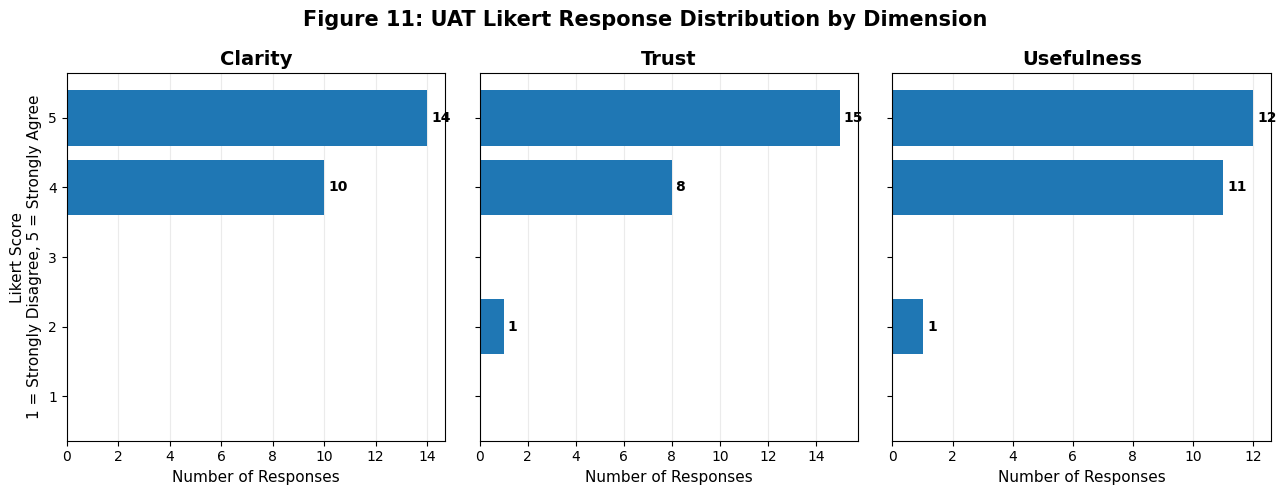

Saved: shap_plots/uat_likert_distribution_dimensions.png


In [4]:
# ============================================================
# FIGURE 11
# LIKERT RESPONSE DISTRIBUTION BY DIMENSION
# Added following supervisor feedback
# ============================================================

dimensions = {
    'Clarity': clarity_cols,
    'Trust': trust_cols,
    'Usefulness': useful_cols
}

likert_scores = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 5),
    sharey=True
)

for ax, (dimension_name, columns) in zip(
    axes,
    dimensions.items()
):

    responses = clean[columns].to_numpy().flatten()

    counts = [
        np.sum(responses == score)
        for score in likert_scores
    ]

    bars = ax.barh(
        likert_scores,
        counts
    )

    ax.set_title(
        dimension_name,
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Number of Responses',
        fontsize=11
    )

    ax.set_yticks(likert_scores)

    ax.set_yticklabels([
        '1',
        '2',
        '3',
        '4',
        '5'
    ])

    ax.grid(
        axis='x',
        alpha=0.25
    )

    ax.set_axisbelow(True)

    # Add response count to each bar
    for bar, count in zip(bars, counts):

        if count > 0:
            ax.text(
                bar.get_width() + 0.15,
                bar.get_y() + bar.get_height() / 2,
                str(count),
                va='center',
                fontsize=10,
                fontweight='bold'
            )

axes[0].set_ylabel(
    'Likert Score\n'
    '1 = Strongly Disagree, '
    '5 = Strongly Agree',
    fontsize=11
)

fig.suptitle(
    'Figure 11: UAT Likert Response Distribution by Dimension',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../shap_plots/uat_likert_distribution_dimensions.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "Saved: "
    "shap_plots/uat_likert_distribution_dimensions.png"
)

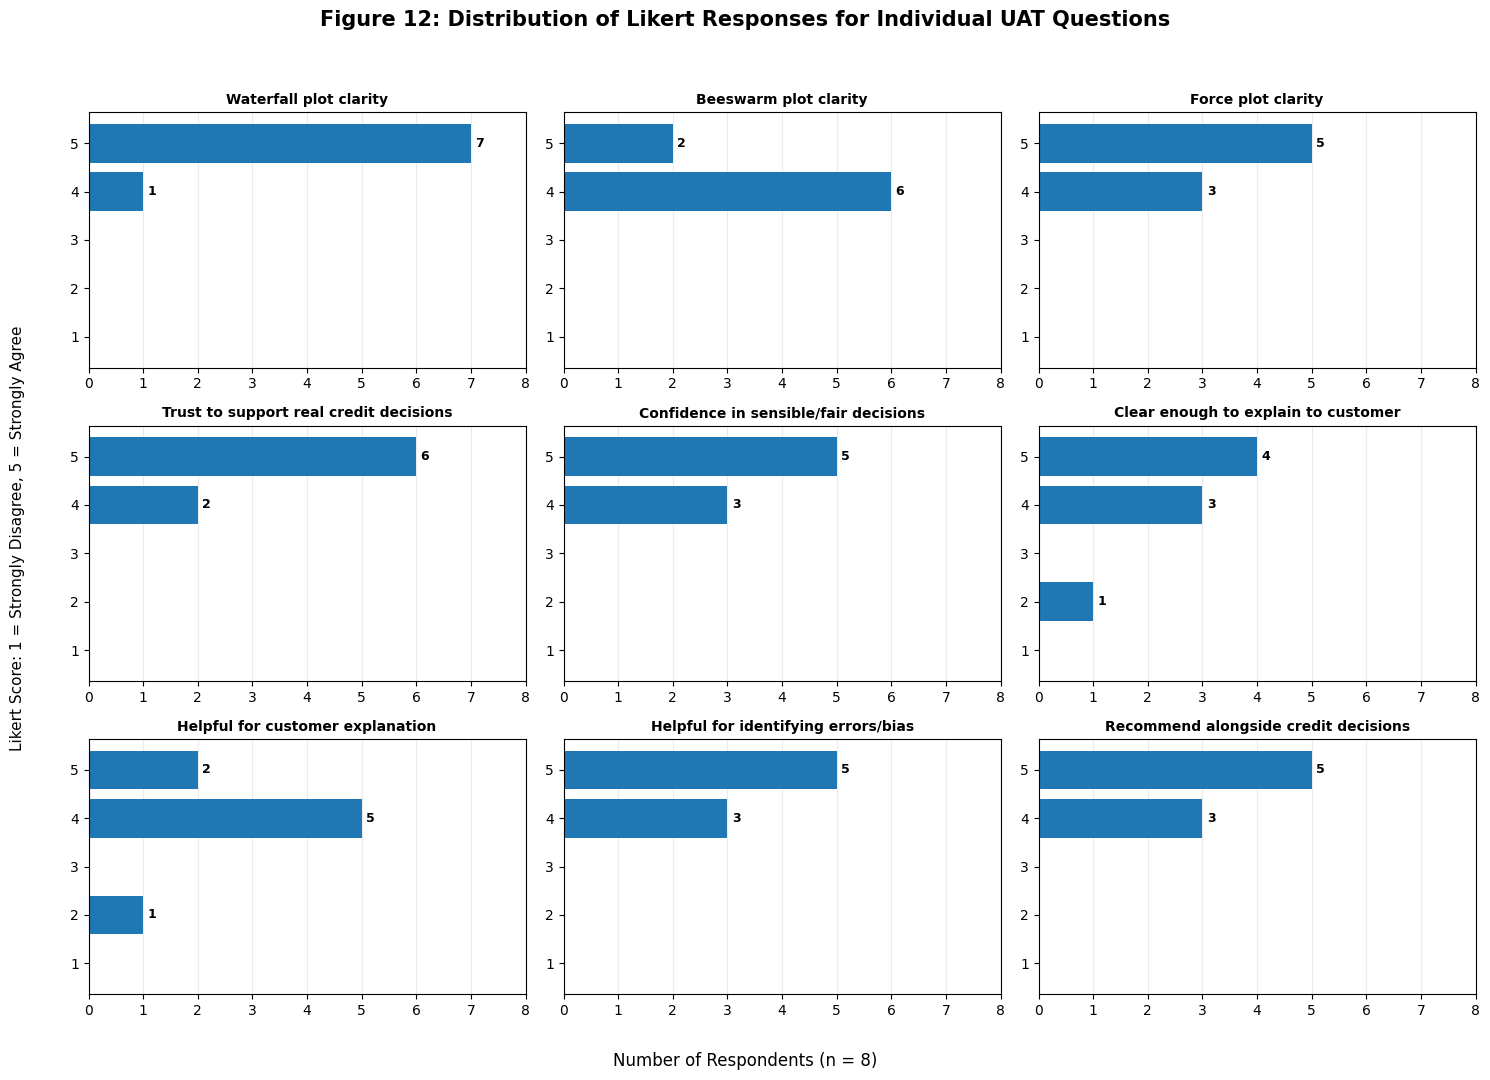

Saved: shap_plots/uat_question_distributions.png


In [5]:
# ============================================================
# FIGURE 12
# DISTRIBUTION OF LIKERT RESPONSES FOR EACH UAT QUESTION
# ============================================================

question_labels = [
    'Waterfall plot clarity',
    'Beeswarm plot clarity',
    'Force plot clarity',
    'Trust to support real credit decisions',
    'Confidence in sensible/fair decisions',
    'Clear enough to explain to customer',
    'Helpful for customer explanation',
    'Helpful for identifying errors/bias',
    'Recommend alongside credit decisions'
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 11)
)

axes = axes.flatten()

for ax, col, label in zip(
    axes,
    all_likert,
    question_labels
):

    counts = (
        clean[col]
        .value_counts()
        .reindex(
            likert_scores,
            fill_value=0
        )
    )

    bars = ax.barh(
        likert_scores,
        counts.values
    )

    ax.set_title(
        label,
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlim(0, 8)

    ax.set_xticks(
        range(0, 9)
    )

    ax.set_yticks(
        likert_scores
    )

    ax.grid(
        axis='x',
        alpha=0.25
    )

    ax.set_axisbelow(True)

    for bar, count in zip(
        bars,
        counts.values
    ):

        if count > 0:
            ax.text(
                bar.get_width() + 0.08,
                bar.get_y() + bar.get_height() / 2,
                str(count),
                va='center',
                fontsize=9,
                fontweight='bold'
            )

fig.text(
    0.5,
    0.02,
    'Number of Respondents (n = 8)',
    ha='center',
    fontsize=12
)

fig.text(
    0.01,
    0.5,
    'Likert Score: '
    '1 = Strongly Disagree, '
    '5 = Strongly Agree',
    va='center',
    rotation='vertical',
    fontsize=11
)

fig.suptitle(
    'Figure 12: Distribution of Likert Responses '
    'for Individual UAT Questions',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0.04, 0.05, 1, 0.95]
)

plt.savefig(
    '../shap_plots/uat_question_distributions.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "Saved: "
    "shap_plots/uat_question_distributions.png"
)

In [6]:
# ============================================================
# LIKERT RESPONSE COUNT TABLE
# ============================================================

distribution_rows = []

for col in all_likert:

    counts = (
        clean[col]
        .value_counts()
        .reindex(
            [1, 2, 3, 4, 5],
            fill_value=0
        )
    )

    distribution_rows.append({
        'Question': col,
        'Strongly Disagree (1)': counts[1],
        'Disagree (2)': counts[2],
        'Neutral (3)': counts[3],
        'Agree (4)': counts[4],
        'Strongly Agree (5)': counts[5]
    })

likert_distribution_df = pd.DataFrame(
    distribution_rows
)

print("=" * 100)
print("UAT LIKERT RESPONSE DISTRIBUTION")
print("=" * 100)

print(
    likert_distribution_df.to_string(
        index=False
    )
)

likert_distribution_df.to_csv(
    '../reports/UAT_Likert_Distribution.csv',
    index=False
)

print(
    "\nSaved: "
    "reports/UAT_Likert_Distribution.csv"
)

UAT LIKERT RESPONSE DISTRIBUTION
        Question  Strongly Disagree (1)  Disagree (2)  Neutral (3)  Agree (4)  Strongly Agree (5)
  clarity_chart1                      0             0            0          1                   7
  clarity_chart2                      0             0            0          6                   2
  clarity_chart3                      0             0            0          3                   5
 trust_workplace                      0             0            0          2                   6
trust_confidence                      0             0            0          3                   5
  trust_customer                      0             1            0          3                   4
  useful_explain                      0             1            0          5                   2
   useful_errors                      0             0            0          3                   5
useful_recommend                      0             0            0          3        

In [7]:
# Open-ended comments

useful_comments = (
    df.iloc[:, 28]
    .dropna()
)

improvement_comments = (
    df.iloc[:, 29]
    .dropna()
)

print("=" * 60)
print("MOST USEFUL — PARTICIPANT COMMENTS")
print("=" * 60)

for i, comment in enumerate(
    useful_comments,
    1
):
    print(f"P{i}: {comment}\n")

print("=" * 60)
print("IMPROVEMENT SUGGESTIONS")
print("=" * 60)

for i, comment in enumerate(
    improvement_comments,
    1
):
    print(f"P{i}: {comment}\n")

with open(
    '../reports/UAT_Open_Comments.txt',
    'w',
    encoding='utf-8'
) as f:

    f.write(
        "UAT OPEN COMMENTS\n"
        + "=" * 60
        + "\n\n"
    )

    f.write("MOST USEFUL:\n\n")

    for i, comment in enumerate(
        useful_comments,
        1
    ):
        f.write(
            f"P{i}: {comment}\n\n"
        )

    f.write(
        "\nIMPROVEMENT SUGGESTIONS:\n\n"
    )

    for i, comment in enumerate(
        improvement_comments,
        1
    ):
        f.write(
            f"P{i}: {comment}\n\n"
        )

print(
    "Saved: "
    "reports/UAT_Open_Comments.txt"
)

MOST USEFUL — PARTICIPANT COMMENTS
P1: I found it useful to see which factors had the biggest impact on the final decision. It helped me understand why the system gave a particular result.

P2: Overall SHAP was useful because it turned a black box prediction into an explanation that can be easily understood and questioned. 

P3: The waterfall plot (Chart 1) and beeswarm plot (Chart 2) are highly useful for audit and compliance purposes. They clearly break down exactly which risk variables drove a specific decision, making it much easier to detect system bias or errors.

P4: It clearly showed which factors influenced the credit decision and whether they increased or decreased the risk.

P5: It made the models decision easier to understand by showing which factors increased or decreased the risk.

P6: They made the AI output more understandable by showing how individual factors affected the final result.

P7: They helped identify the key factors responsible for the models credit-risk p

In [8]:
# Save scored UAT data

clean.to_csv(
    '../data/processed/UAT_scored.csv',
    index=False
)

print(
    "Saved: "
    "data/processed/UAT_scored.csv"
)

print(
    f"\nFinal summary: "
    f"n={len(clean)}"
)

print(
    "Likert distributions are used as the "
    "primary UAT evaluation evidence."
)

print(
    f"Mean scores retained for reference only: "
    f"Clarity={clarity_mean:.2f}, "
    f"Trust={trust_mean:.2f}, "
    f"Usefulness={useful_mean:.2f}"
)

Saved: data/processed/UAT_scored.csv

Final summary: n=8
Likert distributions are used as the primary UAT evaluation evidence.
Mean scores retained for reference only: Clarity=4.58, Trust=4.54, Usefulness=4.42
